# Experiment No. 03

## Principal Component Analysis (PCA) on a Multivariate Dataset

**Name:** Swara Kerkar  
**Roll Number:** 24141027

### Aim
To apply Principal Component Analysis (PCA) on a multivariate dataset in order to reduce its dimensionality, visualize the data in lower dimensions, and evaluate the amount of variance retained after transformation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

## Create Dataset

In [2]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)

df

,Height,Weight,Age,Gender
0,170,65,30,1
1,165,59,25,0
2,180,75,35,1
3,175,68,28,1
4,160,55,22,0
5,172,70,32,1
6,168,62,27,0
7,177,74,33,1
8,162,58,24,0
9,158,54,21,0


## EDA

In [3]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (10, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Height  10 non-null     int64
 1   Weight  10 non-null     int64
 2   Age     10 non-null     int64
 3   Gender  10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes

Statistical Summary:


,Height,Weight,Age,Gender
count,10.000000,10.00000,10.000000,10.000000
mean,168.700000,64.00000,27.700000,0.500000
std,7.439385,7.60117,4.762119,0.527046
min,158.000000,54.00000,21.000000,0.000000
25%,162.750000,58.25000,24.250000,0.000000
50%,169.000000,63.50000,27.500000,0.500000
75%,174.250000,69.50000,31.500000,1.000000
max,180.000000,75.00000,35.000000,1.000000


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Height    0
Weight    0
Age       0
Gender    0
dtype: int64


## Separate features and labels

In [5]:
X = df.drop('Gender', axis=1)
y = df['Gender']

print("Input Features:")
display(X)

print("\nTarget Variable:")
display(y)

Input Features:


,Height,Weight,Age
0,170,65,30
1,165,59,25
2,180,75,35
3,175,68,28
4,160,55,22
5,172,70,32
6,168,62,27
7,177,74,33
8,162,58,24
9,158,54,21



Target Variable:


0    1
1    0
2    1
3    1
4    0
5    1
6    0
7    1
8    0
9    0
Name: Gender, dtype: int64

## Standardization

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

display(X_scaled_df)

,Height,Weight,Age
0,0.184198,0.138675,0.509104
1,-0.524256,-0.693375,-0.597644
2,1.601106,1.525426,1.615851
3,0.892652,0.554700,0.066405
4,-1.232710,-1.248075,-1.261692
5,0.467580,0.832050,0.951803
6,-0.099184,-0.277350,-0.154945
7,1.176034,1.386750,1.173152
8,-0.949329,-0.832050,-0.818993
9,-1.516092,-1.386750,-1.483041


In [7]:
# Verifying Standardization
print("Means:")
print(X_scaled_df.mean())

print("\nStandard Deviations:")
print(X_scaled_df.std(ddof=0))

Means:
Height    1.598721e-15
Weight   -4.440892e-17
Age       1.554312e-16
dtype: float64

Standard Deviations:
Height    1.0
Weight    1.0
Age       1.0
dtype: float64


## Applying PCA

In [8]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

display(X_pca_df)

,PC1,PC2
0,0.479350,0.240059
1,-1.048541,-0.046208
2,2.737638,0.017043
3,0.874626,-0.586085
4,-2.160684,-0.022405
5,1.300132,0.336909
6,-0.307430,-0.032200
7,2.157779,-0.010548
8,-1.501153,0.088028
9,-2.531716,0.015408


## Explained Variance

In [9]:
print("Explained Variance:")
print(pca.explained_variance_)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPercentage of Variance Retained:")
print(pca.explained_variance_ratio_ * 100)

print("\nTotal Variance Retained:",
      pca.explained_variance_ratio_.sum() * 100, "%")

Explained Variance:
[3.26236871 0.05852153]

Explained Variance Ratio:
[0.97871061 0.01755646]

Percentage of Variance Retained:
[97.87106137  1.75564595]

Total Variance Retained: 99.62670732254938 %


In [10]:
variance_df = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2'],
    'Explained Variance': pca.explained_variance_,
    'Variance Ratio': pca.explained_variance_ratio_,
    'Percentage (%)': pca.explained_variance_ratio_ * 100
})

display(variance_df)

,Principal Component,Explained Variance,Variance Ratio,Percentage (%)
0,PC1,3.262369,0.978711,97.871061
1,PC2,0.058522,0.017556,1.755646


## Scree Plot

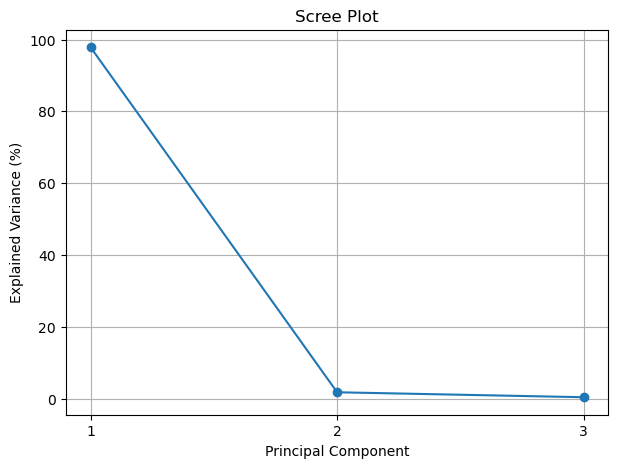

In [11]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance * 100,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)

plt.show()

## Cumulative Variance

In [13]:
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    'Component': range(1, len(explained_variance) + 1),
    'Explained Variance (%)': explained_variance * 100,
    'Cumulative Variance (%)': cumulative_variance * 100
})

display(variance_table)

,Component,Explained Variance (%),Cumulative Variance (%)
0,1,97.871061,97.871061
1,2,1.755646,99.626707
2,3,0.373293,100.000000


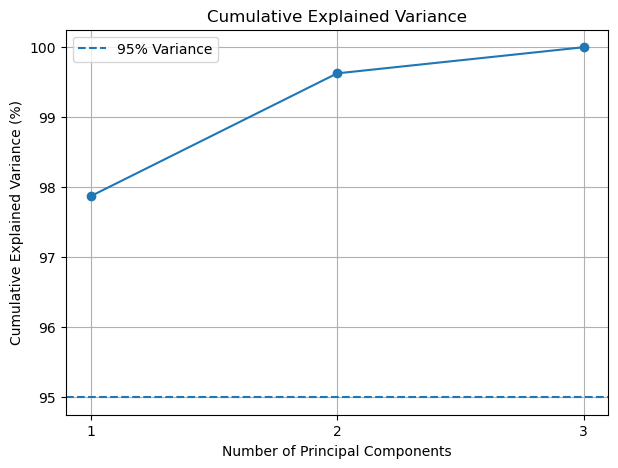

In [14]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker='o'
)

plt.axhline(
    y=95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)

plt.show()

In [15]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Components required to retain at least 95% variance:",
    n_components_95
)

Components required to retain at least 95% variance: 1


## PCA 2D Visualization

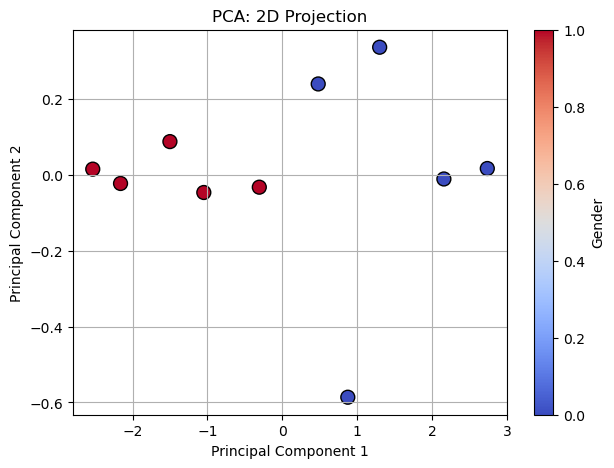

In [16]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=100
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 2D Projection')
plt.colorbar(label='Gender')
plt.grid(True)

plt.show()

## Before vs After PCA

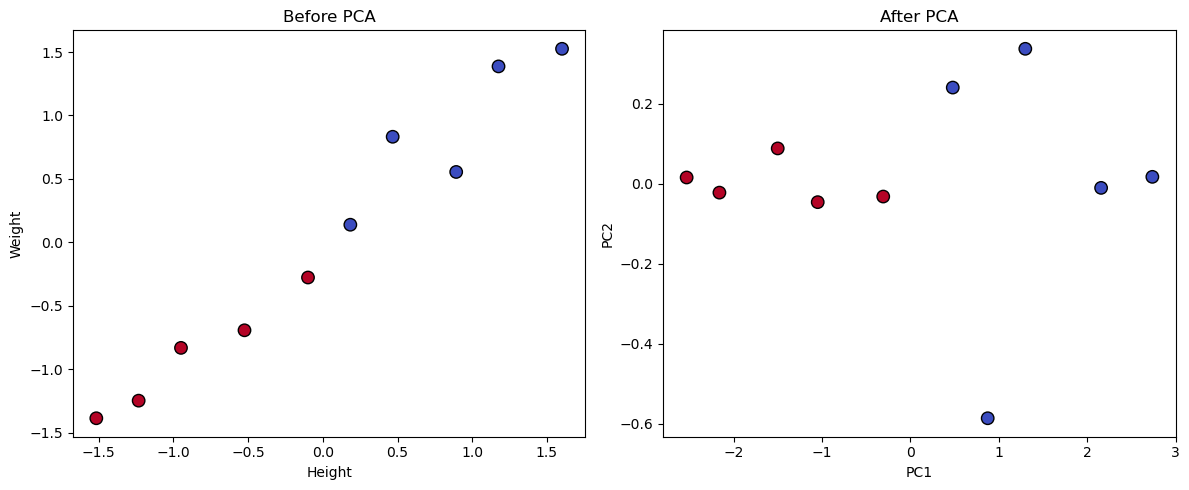

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Before PCA')

plt.subplot(1, 2, 2)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('After PCA')

plt.tight_layout()
plt.show()

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

display(loadings)

,PC1,PC2
Height,0.575755,-0.680522
Weight,0.581400,-0.048971
Age,0.574875,0.731090


## Heatmap

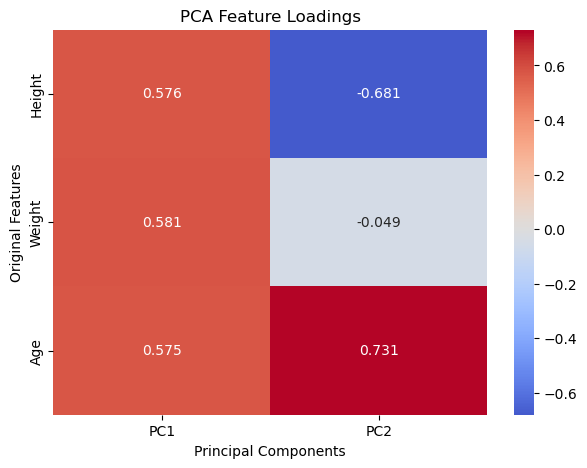

In [19]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    loadings,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0
)

plt.title('PCA Feature Loadings')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')

plt.show()

## Covariance Matrix

In [20]:
cov_matrix = np.cov(X_scaled.T)

cov_df = pd.DataFrame(
    cov_matrix,
    columns=X.columns,
    index=X.columns
)

display(cov_df)

,Height,Weight,Age
Height,1.111111,1.089427,1.052758
Weight,1.089427,1.111111,1.084580
Age,1.052758,1.084580,1.111111


## Eigenvalues and Eigenvectors

In [21]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = eigenvalues.argsort()[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[3.26236871 0.05852153 0.01244309]

Eigenvectors:
[[-0.57575457 -0.68052174  0.45320728]
 [-0.58139955 -0.04897084 -0.8121431 ]
 [-0.57487498  0.73108961  0.36745984]]


In [22]:
print("Scikit-learn Explained Variance:")
print(pca.explained_variance_)

print("\nManual Eigenvalues:")
print(eigenvalues)

print("\nDifference:")
print(pca.explained_variance_ - eigenvalues[:2])

Scikit-learn Explained Variance:
[3.26236871 0.05852153]

Manual Eigenvalues:
[3.26236871 0.05852153 0.01244309]

Difference:
[-1.77635684e-15  5.55111512e-17]


## Reconstruction Error

In [23]:
X_reconstructed = pca.inverse_transform(X_pca)

reconstruction_error = np.mean(
    (X_scaled - X_reconstructed) ** 2
)

print("Mean Squared Reconstruction Error:",
      reconstruction_error)

Mean Squared Reconstruction Error: 0.003732926774506173


## PCA without scaling

In [24]:
pca_unscaled = PCA(n_components=2)

X_pca_unscaled = pca_unscaled.fit_transform(X)

print("Variance Ratio Without Scaling:")
print(pca_unscaled.explained_variance_ratio_)

print(
    "\nTotal Variance Retained Without Scaling:",
    pca_unscaled.explained_variance_ratio_.sum() * 100,
    "%"
)

Variance Ratio Without Scaling:
[0.98273788 0.01347543]

Total Variance Retained Without Scaling: 99.62133063372927 %


## PCA with scaling

In [25]:
pca_scaled = PCA(n_components=2)

X_pca_scaled = pca_scaled.fit_transform(X_scaled)

print("Variance Ratio With Scaling:")
print(pca_scaled.explained_variance_ratio_)

print(
    "\nTotal Variance Retained With Scaling:",
    pca_scaled.explained_variance_ratio_.sum() * 100,
    "%"
)

Variance Ratio With Scaling:
[0.97871061 0.01755646]

Total Variance Retained With Scaling: 99.62670732254938 %


## Comparison

In [26]:
scaling_comparison = pd.DataFrame({
    'Method': ['Without Scaling', 'With Scaling'],
    'PC1 Variance (%)': [
        pca_unscaled.explained_variance_ratio_[0] * 100,
        pca_scaled.explained_variance_ratio_[0] * 100
    ],
    'PC2 Variance (%)': [
        pca_unscaled.explained_variance_ratio_[1] * 100,
        pca_scaled.explained_variance_ratio_[1] * 100
    ],
    'Total Variance Retained (%)': [
        pca_unscaled.explained_variance_ratio_.sum() * 100,
        pca_scaled.explained_variance_ratio_.sum() * 100
    ]
})

display(scaling_comparison)

,Method,PC1 Variance (%),PC2 Variance (%),Total Variance Retained (%)
0,Without Scaling,98.273788,1.347543,99.621331
1,With Scaling,97.871061,1.755646,99.626707


## Train test split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 7
Testing Samples: 3


## Logistic Regression

In [28]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual Labels:")
print(y_test.values)

print("\nPredicted Labels:")
print(y_pred)

Actual Labels:
[0 0 1]

Predicted Labels:
[0 0 1]


In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Classification Accuracy:",
      accuracy * 100, "%")

Classification Accuracy: 100.0 %


## Confusion Matrix

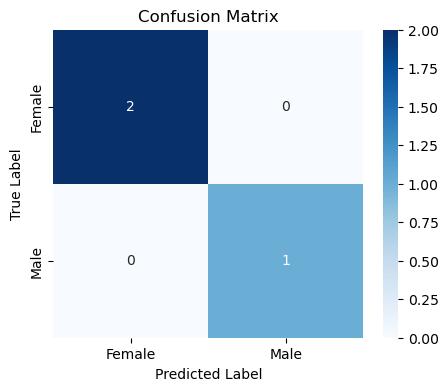

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

## Summary

In [31]:
original_dimensions = X.shape[1]
reduced_dimensions = X_pca.shape[1]
variance_retained = pca.explained_variance_ratio_.sum() * 100

print("PCA SUMMARY")
print("-" * 35)
print("Original Dimensions      :", original_dimensions)
print("Reduced Dimensions       :", reduced_dimensions)
print("Dimensions Reduced       :", original_dimensions - reduced_dimensions)
print("Variance Retained        :", round(variance_retained, 2), "%")
print("Reconstruction Error     :", round(reconstruction_error, 5))
print("Classification Accuracy  :", round(accuracy * 100, 2), "%")

PCA SUMMARY
-----------------------------------
Original Dimensions      : 3
Reduced Dimensions       : 2
Dimensions Reduced       : 1
Variance Retained        : 99.63 %
Reconstruction Error     : 0.00373
Classification Accuracy  : 100.0 %


# Conclusion

Principal Component Analysis (PCA) was successfully applied to a multivariate dataset containing Height, Weight, and Age features. The features were first standardized to ensure that differences in scale did not affect the PCA transformation.

The original three-dimensional feature space was reduced to two principal components while retaining a significant portion of the total variance. The explained variance ratio and cumulative variance were analyzed to evaluate the effectiveness of dimensionality reduction.

The PCA-transformed data was visualized in two dimensions, making it easier to interpret the structure of the dataset. PCA loadings were also analyzed to determine the contribution of the original features to each principal component.

The PCA implementation was further verified mathematically using the covariance matrix, eigenvalues, and eigenvectors. Reconstruction error was calculated to measure the information lost during dimensionality reduction. PCA with and without standardization was also compared, demonstrating the importance of feature scaling.

Finally, the reduced PCA features were supplied to a Logistic Regression classifier and evaluated using accuracy and a confusion matrix.

Thus, PCA provides an effective method for reducing dimensionality while preserving important information, simplifying visualization, and providing compact features for subsequent machine learning tasks. However, dimensionality reduction involves a trade-off between reducing the number of features and losing some information from the original dataset.